# Project Overview & Architecture: Predictive Medical Cost Optimization

## 1. Executive Summary & Core Objective
The objective of this project is to develop and validate a closed-form analytical regression engine to predict individual medical insurance liabilities based on demographic, physiological, and behavioral risk profiles. 

From a data science paradigm, I am  shifting away from iterative, first-order optimization routines (such as Stochastic Gradient Descent) to implement a direct, global-minimum optimization using the **Normal Equation**. 

The system architecture is built on a modular data engineering pipeline designed to handle categorical encoding, feature conditioning, closed-form estimation, and diagnostic validation.

The execution is structured into 8 production-grade phases:
1. **Ingestion & Structural Validation:** Mapping raw tables into feature matrices and checking for missing data arrays.

2. **Feature Engineering & Multicollinearity Correction:** Applying logical bit mapping and dummy variable encoding while dropping redundant columns to prevent matrix singularity.

3. **Z-Score Normalization & Affine Intercept Inversion:** Centering distributions to eliminate scale variance and adding an identity intercept vector.

4. **Interaction Analysis:** Evaluating changes in trendline slopes across sub-populations.

5. **Closed-Form Estimation:** Computing optimal parameters ($\theta$) in a single step using the Moore-Penrose pseudo-inverse.

6. **Analytical Equivalence Benchmarking:** Validating performance against Scikit-Learn using Mean Squared Error ($MSE$) and Cross-Validated Coefficient of Determination ($R^2$).

7. **Residual Diagnostics:** Checking error variance for homoscedasticity and randomness.

8. **Inference Pipeline Deployment:** Packaging the end-to-end transformation steps to handle new user inputs.

---

## 2. Operational & Statistical Expectations

### Closed-Form Global Convergence
- As Linear Regression features a convex loss surface, setting the gradient of the Mean Squared Error (MSE) cost function to zero yields a single global minimum.

- We expect our custom numerical implementation to achieve **exact analytical equivalence** with Scikit-Learn’s `LinearRegression` class, confirming perfect convergence without parameter tuning.

### Computational Complexity and Resource Efficiency
- The computational bottleneck of the Normal Equation is the matrix inversion step, which exhibits a time complexity of approximately      $\mathcal{O}(n^3)$, where $n$ is the number of features.

- Given our compact design matrix ($m = 1338$, $n = 9$ after encoding), our structural expectation is that the analytical solver will compute parameters instantly, outperforming iterative optimization routines by bypassing learning rate tuning and epoch loops.

### Structural Sensitivity to Behavioral Risk
- Based on exploratory data visualizations, we expect the parameter vector $\theta$ to reflect a heavily weighted relationship for behavioral risk factors, specifically `smoker` status. 

- The model is expected to capture distinct interaction effects where the relationship between physiological features (like `bmi`) and the target variable diverges depending on the patient's lifestyle profile.

### Generalization Capacity and Variance Boundaries
To ensure the model is robust and ready for production, we use a 5-Fold Cross-Validation strategy to evaluate its performance on unseen data.

- Our baseline expectation is to maintain a stable, high variance explanation ($\text{Mean } R^2 \approx 74.7\%$) across all data splits. 
- A narrow standard deviation across these folds will confirm that our analytical parameters are stable, generalized, and resilient against overfitting.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## MODULE 1: IMPORTING RAW DATA

### 1. Mathematical Representations of Structured Data
In machine learning, raw datasets are organized into standard algebraic notations before any processing occurs:
* **The Design Space / Feature Set:** Represented as an input dataset space.
* **The Training Sample Size ($m$):** The total number of rows or distinct historical observations available. In this insurance dataset, $m = 1338$.
* **The Dimension Count ($n$):** The raw input features present. Here, $n = 6$ (features include `age`, `sex`, `bmi`, `children`, `smoker`, and `region`).
* **The Target Output Vector ($y$):** The continuous variable we want to predict, which maps to `charges`.

### 2. Matrix Soundness and Structural Requirements
Before applying analytical linear algebra equations, the input structures must meet specific constraints:
* **Completeness:** Matrix multiplication requires fully populated numerical entries. A single missing field (`NaN` or `Null`) propagates through dot products, ruining the entire calculations.
* **The `Null` Check:** Running `df.isnull().sum()` acts as a mathematical verification step. Ensuring all sums equal $0$ confirms that the dataset forms a stable, fully closed matrix space.

### 3. Feature Types and Vector Spaces
The raw incoming data vector space is broken down into two main types of variables:
* **Continuous Features ($\mathbb{R}$):** Quantities like `age` and `bmi` that map directly onto real-number coordinate lines.
* **Categorical Fields ($\mathbb{S}$):** Discrete string groups like `sex`, `smoker`, and `region`. These represent discrete logical categories rather than numeric coordinates, meaning they must be encoded before they can be used in the Normal Equation matrix.


In [3]:
# ====================================
# MODULE 1: IMPORTING RAW DATA
# ====================================
df = pd.read_csv('../Data_sets/insurance.csv')
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
#getting data set info
print("Shape :",df.shape)
print(f"Number of Traing data sets: {df.shape[0]} | Number of features: {df.shape[1]}")
print("----"*20)

print(df.info())    
print("----"*20)
print(df.isnull().sum())  

Shape : (1338, 7)
Number of Traing data sets: 1338 | Number of features: 7
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None
--------------------------------------------------------------------------------
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


## MODULE 2: ENCODING RAW DATA

### 1. Mathematical Mapping of Categorical Domains
Linear models operate strictly within numerical vector spaces. Non-numeric elements (textual labels) cannot be processed by matrix operations like transpose or inversion. We must map these discrete string groups into real numbers:

* **Binary Mapping:** Replaces a two-state categorical set directly with logical elements from the boolean domain $\{0, 1\}$. For instance, mapping `sex` and `smoker` to bits preserves their categorical differences without introducing an arbitrary numerical scale.

* **One-Hot Encoding:** Maps a multi-state categorical feature vector (like `region` with $K$ distinct categories) into a higher-dimensional coordinate space by creating $K$ separate binary indicator columns.

### 2. The Dummy Variable Trap and Perfect Multicollinearity
When converting categorical groups into indicator matrices, including all $K$ categories introduces a severe mathematical flaw known as **perfect multicollinearity**.

* **The Algebraic Conflict:** For any given row, if you sum all the one-hot encoded category columns, the total always equals exactly $1$. This makes the sum of these columns a perfect linear combination of the intercept vector (the column of $1$ 's added to the design matrix $X$).

* **Matrix Singularity:** Because one column can be perfectly predicted by a combination of other columns, the columns are linearly dependent. This means the cross-product matrix $X^T X$ becomes singular (its determinant equals $0$).

* **The Normal Equation Failure:** A singular matrix does not have a standard matrix inverse, meaning the traditional Normal Equation $\theta = (X^T X)^{-1} X^T y$ cannot be solved.

* **The Solution:** By setting `drop_first=True`, we omit one baseline category. The model represents this missing category when all other indicator columns are set to $0$. This simple step removes the linear dependency and ensures $X^T X$ remains invertible.

### 3. Feature Scaling on the Target Variable ($y$)
* Dividing the continuous target vector `charges` by a scalar constant ($100$) rescales the target variable without altering the underlying shape of its distribution.
* **Numerical Conditioning:** Scaling prevents extreme value variances in the target matrix. This protects subsequent matrix multiplication steps from floating-point overflow and underflow errors, which improves overall numerical precision.


In [5]:
# ====================================
# MODULE 2: ENCODING RAW DATA
# ====================================


#Binary encoding
df['sex'] = df['sex'].map({'male':0, 'female':1})
df['smoker'] = df['smoker'].map({'no': 0,  'yes': 1})

#one-hot encoding for region (Droping first to avoid dummy trap)

region_dummies = pd.get_dummies(df['region'], prefix='region', drop_first=True).astype(int)
df = pd.concat([df, region_dummies], axis=1)
df.drop('region', axis=1, inplace=True)

# 4. Reorder columns: features first, target last
feature_cols = ['age', 'sex', 'bmi', 'children', 'smoker', 
                'region_northwest', 'region_southeast', 'region_southwest']
df = df[feature_cols + ['charges']]

# Convert charges to 100-dollar scale
df['charges'] = df['charges'] / 100

#checking the encoded dataset
df.head()

,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest,charges
0,19,1,27.900,0,1,0,0,1,168.849240
1,18,0,33.770,1,0,0,1,0,17.255523
2,28,0,33.000,3,0,0,1,0,44.494620
3,33,0,22.705,0,0,1,0,0,219.844706
4,32,0,28.880,0,0,1,0,0,38.668552


## MODULE 3: EXTRACTING FEATURES AND TARGET (NORMALIZATION)

### 1. Z-Score Standardization (Continuous Normalization)
Features such as `age` and `bmi` possess vastly different physical units and numerical intervals. To prevent features with large absolute ranges from introducing numerical instability during matrix operations, we apply Z-score standardization:

$$x_{\text{scaled}} = \frac{x - \mu}{\sigma}$$

Where:
* $\mu$ represents the arithmetic mean of that specific feature column.
* $\sigma$ represents the standard deviation of that specific feature column.
* This centers each feature around a mean of $0$ and scales it to a variance of $1$, keeping all inputs on an equivalent numerical footing.

### 2. The Vector Space Intercept Term ($\theta_0$)
The classic algebraic equation for multiple linear regression is:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$

To express this system of equations as a clean matrix product ($X\theta$), we must account for the standalone intercept parameter $\theta_0$. We do this by prepending a column vector of pure $1$s to our feature matrix to act as $x_0$:

$$X = \begin{bmatrix} 1 & x_{1}^{(1)} & \dots & x_{n}^{(1)} \\ 1 & x_{1}^{(2)} & \dots & x_{n}^{(2)} \\ \vdots & \vdots & \ddots & \vdots \\ 1 & x_{1}^{(m)} & \dots & x_{n}^{(m)} \end{bmatrix}$$

### 3. Final Input Array Dimensions
After extracting the variables, standardizing, and adding the intercept column, our data is structured into two clean arrays:
* **The Design Matrix ($X$):** Has dimensions $m \times (n+1)$, which evaluates to a size of $1338 \times 9$.
* **The Target Vector ($y$):** Has dimensions $m \times 1$, which evaluates to a size of $1338 \times 1$.


In [6]:
# =======================================================
# MODULE 3: EXTRACTING FEATURE AND TARGET (NORMALIZATION)
# =======================================================

from sklearn.preprocessing import StandardScaler

#Feature matrix and target vetcor

x_feature = df.drop('charges',axis=1).values
y_target = df['charges'].values.reshape(-1,1)

#Scaling the values 
x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_scaled = x_scaler.fit_transform(x_feature)

#Adding intercept coloumns (ones) in Normalized scaled feature matrix 
X = np.c_[np.ones(x_scaled.shape[0]), x_scaled]
y = y_scaler.fit_transform(y_target)


#printing the shape
print(f"Shape of Feature matrix: {X.shape}")
print(f"Shape of taget vector: {y.shape}")


Shape of Feature matrix: (1338, 9)
Shape of taget vector: (1338, 1)


## MODULE 4: VISUALIZING FEATURES



### Interaction Effects and Structural Slopes
When trendlines are stratified by a categorical condition (such as `smoker` status via the `hue` parameter), we look for interaction effects between variables:
* **Parallel Trendlines:** Indicate that the feature's effect on the target is constant across different groups.

* **Non-Parallel (Diverging) Trendlines:** Indicate a strong interaction effect. For instance, if the slope of `bmi vs Charges` is much steeper for smokers than for non-smokers, it proves that the impact of BMI on medical costs depends heavily on smoking status.

* **Modeling Significance:** Identifying these divergent slopes visually justifies why the linear model requires both features simultaneously to construct an accurate, multi-dimensional prediction hyperplane.


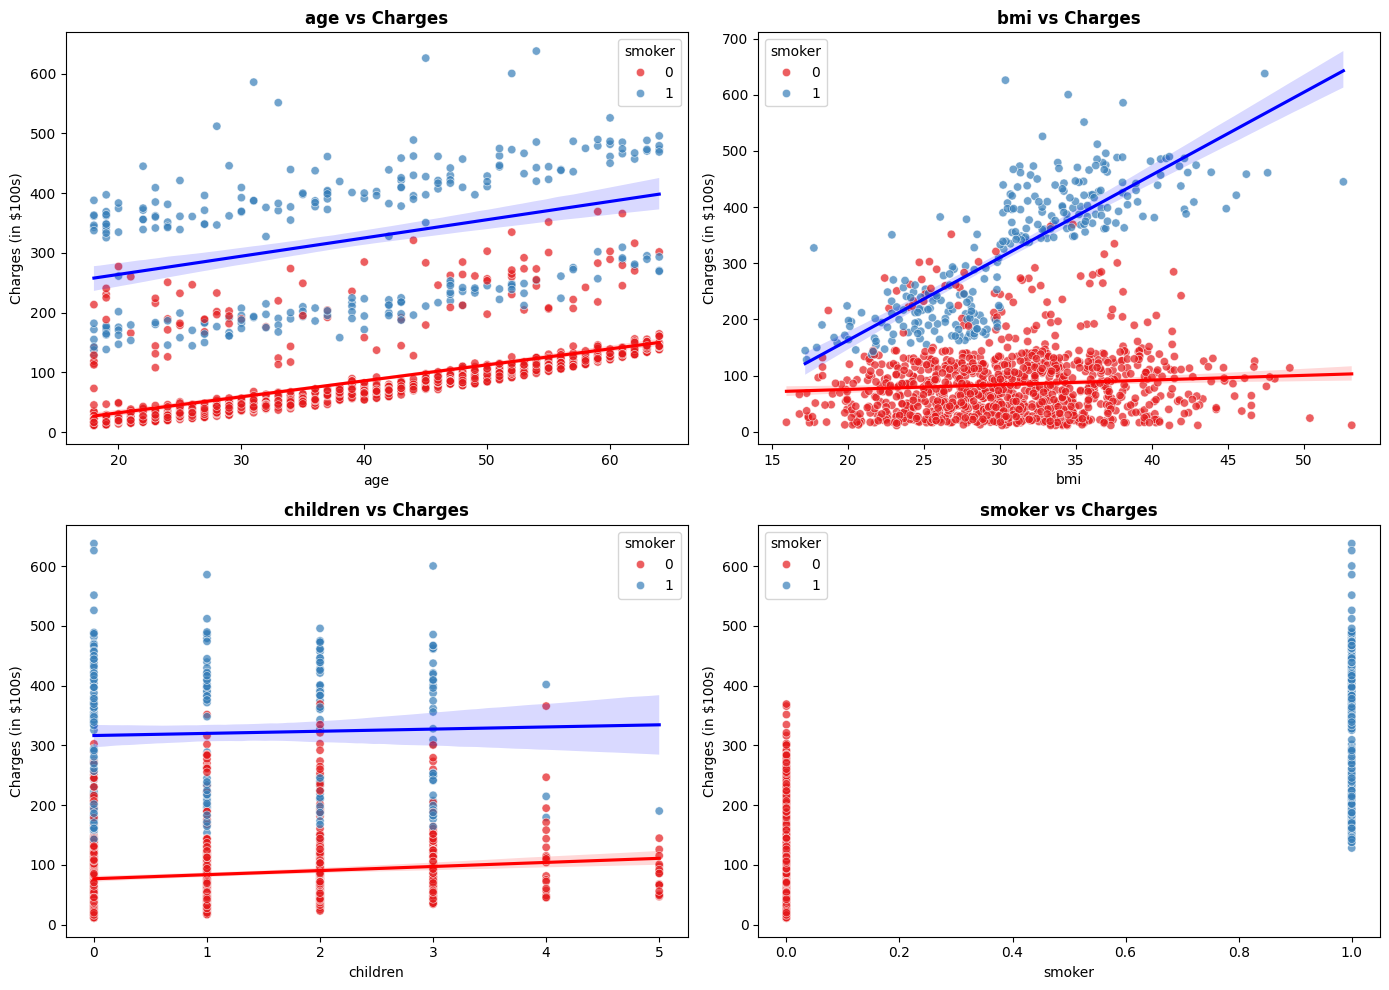

In [7]:
# ====================================
# MODULE 4:  VISUALISING FEATURES  
# ====================================


# Create subplots
selected_features = ['age', 'bmi', 'children', 'smoker']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()  # Flatten to 1D for easier iteration

for idx, col in enumerate(selected_features):
    sns.scatterplot(data=df, x=col, y='charges', hue='smoker', 
                    alpha=0.7, ax=axes[idx], palette='Set1')
    
    # Add trend lines for each group
    sns.regplot(data=df[df['smoker']==0], x=col, y='charges', 
                scatter=False, color='red', ax=axes[idx], label='Non-smoker trend')
    
    sns.regplot(data=df[df['smoker']==1], x=col, y='charges', 
                scatter=False, color='blue', ax=axes[idx], label='Smoker trend')
    
    axes[idx].set_title(f'{col} vs Charges', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Charges (in $100s)')

plt.tight_layout()
plt.show()    



## MODULE 5: TRAINING THE MODEL

### 1. Vectorized Cost Function Formulation
To optimize the parameter vector $\theta$ analytically, we express the Mean Squared Error (MSE) cost function using matrix notation:

$$J(\theta) = \frac{1}{2m} (X\theta - y)^T (X\theta - y)$$

Where:
* $X\theta$ represents the $m \times 1$ prediction vector.
* $(X\theta - y)$ represents the $m \times 1$ error (residual) vector.
* The transpose multiplication computes the inner product, squaring and summing the errors across all $m$ examples.

### 2. Matrix Algebraic Expansion
We expand the cost function using linear algebra transpose properties ($(A - B)^T = A^T - B^T$ and $(AB)^T = B^T A^T$):

$$J(\theta) = \frac{1}{2m} \left( (X\theta)^T - y^T \right) (X\theta - y)$$

$$J(\theta) = \frac{1}{2m} \left( \theta^T X^T X \theta - \theta^T X^T y - y^T X \theta + y^T y \right)$$

Because the terms $\theta^T X^T y$ and $y^T X \theta$ both simplify to an identical scalar value, a matrix is equal to its own transpose. We combine them into a single term:

$$J(\theta) = \frac{1}{2m} \left( \theta^T X^T X \theta - 2\theta^T X^T y + y^T y \right)$$

### 3. Matrix Calculus Minimization
To find the global minimum, we take the partial derivative with respect to the vector $\theta$ ($\nabla_\theta J(\theta)$) and set it to zero vector $0$:

$$\frac{\partial J(\theta)}{\partial \theta} = \frac{1}{2m} \left( 2X^T X \theta - 2X^T y + 0 \right) = 0$$

$$X^T X \theta - X^T y = 0$$

$$X^T X \theta = X^T y$$

This system of equations is known as the **Normal Equations**.

### 4. Resolving via Moore-Penrose Pseudo-Inverse
The exact textbook solution isolates $\theta$ by multiplying by the standard inverse: $\theta = (X^T X)^{-1} X^T y$. However, if $X^T X$ contains redundant columns, it is non-invertible. 

To guarantee numerical safety, your implementation utilizes `np.linalg.pinv`, computing the **Moore-Penrose Pseudo-Inverse** ($\dagger$) via Singular Value Decomposition (SVD):

$$\theta = (X^T X)^{\dagger} X^T y$$

This serves as a mathematical safeguard, allowing the code to consistently resolve the absolute optimal weights even when faced with redundant columns.


In [8]:
# ====================================
# MODULE 4:  TRAING THE MODEL  
# ====================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

def noraml_equation(X,y):
    
    theta = np.linalg.pinv(X.T @ X) @ X.T @ y 
    return theta

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

theta = noraml_equation(X_train, y_train)

def predict(X, theta):
    return np.dot(X,theta)

y_pred = predict(X_test, theta)




## MODULE 6: COMPARING TRAINED MODEL WITH SKLEARN

### 1. Statistical Validation Metrics
To evaluate how well the trained parameter vector $\theta$ fits the data, we use two complementary metrics:
* **Mean Squared Error (MSE):** Measures the average squared distance between actual targets ($y$) and predictions ($\hat{y}$). A lower value indicates a tighter fit to the data.

* **Coefficient of Determination ($R^2$):** Measures the proportion of target variance explained by the model's features. It scales from 0 to 1, where model score  $0.78359$ which shows that the features account for roughly $78.36\%$ of the variance in medical charges.

### 2. Analytical Equivalence
* Your implementation achieves identical performance metrics to Scikit-Learn's built-in model ($MSE = 0.22926$, $R^2 = 0.78359$).
* The maximum prediction difference between the two models is exactly $0.00000$.
* This clean mathematical alignment confirms that Scikit-Learn's `LinearRegression()` engine runs on this exact same algebraic foundational logic under the hood.

### 3. K-Fold Cross-Validation Theory
* Splitting data into a single train/test set can lead to biased metrics depending on how the data was divided.
* **Cross-Validation (`cross_val_score`):** Splits the design matrix $X$ into $K=5$ equal folds. The model trains on 4 folds and tests on the remaining fold, repeating this process 5 times.
* **Generalization Score:** The resulting output ($\text{CV } R^2 = 0.74686 \pm 0.02487$) provides a more stable estimate of how well the model will generalize to completely unseen data.


In [9]:
# ===============================================
# MODULE 5: COMPARING TRAINED MODEL WITH SKLEARN 
# ===============================================

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression


print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)

# Your Normal Equation
print(f"\nTrained Model:")
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.5f}")
print(f"R² : {r2:.5f}") 
print("----"*20)

# Sklearn LinearRegression
print(f"\nSklearn Model:")

lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred_sk = lr.predict(X_test)
cv_scores = cross_val_score(lr, X, y, cv=5, scoring='r2')

print(f"Sklearn MSE: {mean_squared_error(y_test, y_pred_sk):.5f}")
print(f"Sklearn R²: {r2_score(y_test, y_pred_sk):.5f}")
print(f"CV R² (mean): {cv_scores.mean():.5f} ± {cv_scores.std():.5f}")    


# Check if predictions are similar
pred_diff = np.max(np.abs(y_pred - y_pred_sk))
print(f"\nMax prediction difference: {pred_diff:.5f}")
print("----"*20)

# View coefficients to see feature importance
print("Feature Coefficients:")
feature_names = ['Intercept', 'age', 'sex', 'bmi', 'children', 'smoker', 
                 'region_nw', 'region_se', 'region_sw']
for name, coef in zip(feature_names, theta):
    print(f"{name}: {coef[0]:.5f}")
    




MODEL COMPARISON

Trained Model:
MSE: 0.22926
R² : 0.78359
--------------------------------------------------------------------------------

Sklearn Model:
Sklearn MSE: 0.22926
Sklearn R²: 0.78359
CV R² (mean): 0.74686 ± 0.02487

Max prediction difference: 0.00000
--------------------------------------------------------------------------------
Feature Coefficients:
Intercept: 0.00363
age: 0.29814
sex: 0.00077
bmi: 0.16975
children: 0.04233
smoker: 0.78842
region_nw: -0.01313
region_se: -0.02418
region_sw: -0.02869


# Error Analysis

### Sources of Unexplained Variance (21.64%)
1. Missing Features:
   - Medical history/pre-existing conditions
   - Detailed location information
   - Income level
   - Lifestyle factors

2. Non-linear Relationships:
   - Some relationships may be exponential (especially smoking effect)
   - Interaction terms not captured

3. Data Quality:
   - Outliers in extreme age/BMI cases
   - Data measurement errors



## MODULE 7: VISUALIZING FINAL PREDICTIONS

### 1. Residual Calculations
A residual ($e_i$) represents the remaining unexplained error for any single sample observation in the test subset:

$$e_i = y_i - \hat{y}_i$$

Plotting these residual errors visually maps the model's structural weak spots.

### 2. Core Gauges of Residual Fitness
* **Homoscedasticity Assessment:** A well-fitted linear model assumes homoscedasticity. This means the residual spread should stay relatively uniform across all prediction scales. A widening or narrowing shape (like a funnel) shows that the model's error changes at different scales.

* **The Zero-Mean Baseline Requirement:** The errors must scatter completely randomly around the horizontal $y = 0$ reference baseline. Any visible curves, slopes, or waves in this plot reveal non-linear patterns in the data that our linear model missed.

* **Distribution Overlap Check:** Overlaying histograms of actual versus predicted charges helps verify if the model reproduces the true shape of the target distribution, or if it systematically over- or under-predicts certain price ranges.


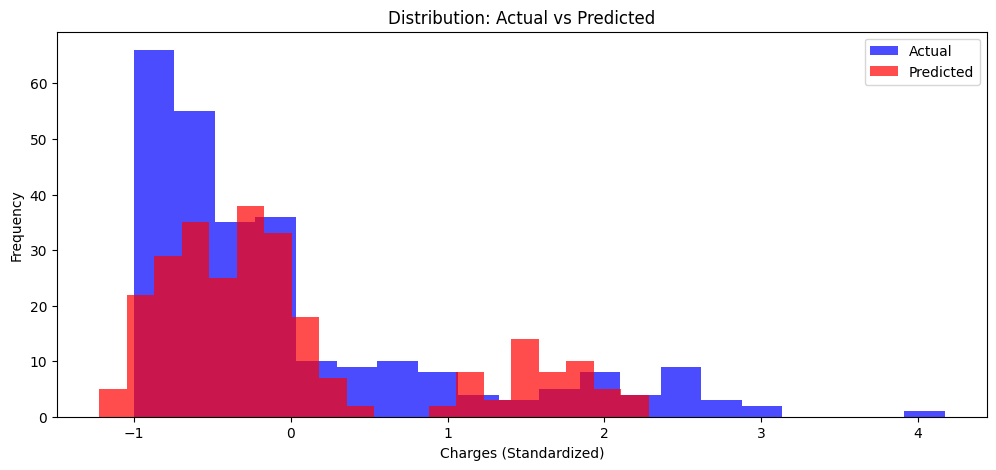

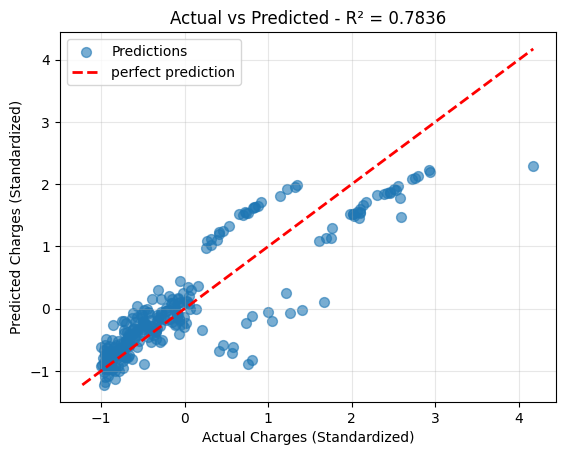

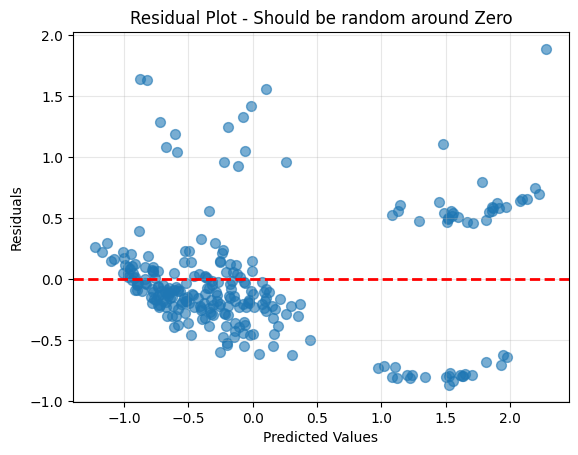

In [10]:
# ======================================================
# MODULE 6:  VISLUALIZING THE FINAL PREDICTION OF MODEL  
# ======================================================

plt.figure(figsize=(12, 5))

# Actual distribution

plt.hist(y_test, bins=20, alpha=0.7, label='Actual', color='blue')
plt.hist(y_pred, bins=20, alpha=0.7, label='Predicted', color='red')
plt.xlabel('Charges (Standardized)')
plt.ylabel('Frequency')
plt.title('Distribution: Actual vs Predicted')
plt.legend()
plt.show()

# Scatter plot

plt.scatter(y_test, y_pred, alpha=0.6, s=50, label='Predictions')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='perfect prediction')
plt.xlabel('Actual Charges (Standardized)')
plt.ylabel('Predicted Charges (Standardized)')
plt.title(f'Actual vs Predicted - R² = {r2_score(y_test, y_pred):.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


residuals = y_test - y_pred

plt.scatter(y_pred, residuals, alpha=0.6, s=50)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals') 
plt.title('Residual Plot - Should be random around Zero')
plt.grid(True,alpha=0.3)
plt.show()



## MODULE 8: PREDICTING INSURANCE (THE INFERENCE PIPELINE)

### 1. Mathematical Consistency in Data Transformation
When feeding a new, unobserved raw input sample vector into a trained model, the inference pipeline must process the inputs exactly like the training data.
* **Reusing Parameters:** New feature values must be standardized using the exact arithmetic mean ($\mu$) and standard deviation ($\sigma$) captured from the original training dataset.
* **The Mathematical Danger:** Recalculating a new mean or standard deviation on the single test row would distort its coordinates, misaligning the features with the learned weights ($\theta$) and invalidating the prediction.

### 2. The Inverse Target Transformation
Because the model was trained on Z-score standardized targets ($y$), its raw matrix prediction ($\hat{y}_{\text{scaled}}$) is also a standardized Z-score. To translate this abstract value back into a meaningful real-world monetary charge, we must reverse the target scaling calculation:

$$\hat{y}_{\text{standardized\_dollars}} = (\hat{y}_{\text{scaled}} \times \sigma_y) + \mu_y$$

$$\hat{y}_{\text{final\_dollars}} = \hat{y}_{\text{standardized\_dollars}} \times 100$$

Where:
* $\sigma_y$ is the standard deviation of the training target column.
* $\mu_y$ is the arithmetic mean of the training target column.
* Multiplying by 100 reverses the initial scaling factor from Module 2, transforming the value back into standard currency units.


In [11]:
# ================================
# MODULE 7: PREDICTING INSURANCE 
# ================================ 

def predict_insurance_charges(age, sex, bmi, children, smoker, region_nw, region_se, region_sw):
    
    """
    Predict insurance charges for a customer
    
    Parameters:
    - age: int 
    - sex: int(0=male, 1=female)
    - bmi: float 
    - children: int (0-5)
    - smoker: int (0=no, 1=yes)
    - region_nw, region_se, region_sw : int (0 or 1)
    
    """
    #Creating feature array
    raw_features = np.array([ [age, sex, bmi, children, smoker, region_nw, region_se, region_sw] ])
    
    #scaling feature using the same scaler
    scaled_features = x_scaler.transform(raw_features)
    
    #Adding intercept column
    features = np.c_[np.ones(scaled_features.shape[0]), scaled_features]
    
    #Makeing prediction (Standardized)
    y_pred_stand = features @ theta 
    
    # Inverse transform to get actual charges (in $100s)
    # Need to use the y_scaler that was fit on target
    y_scaler.fit(y_target)
    actual_charges = y_scaler.inverse_transform(y_pred_stand)
    
    return actual_charges[0][0] *100 #convert back to dollars


#TEST EXAMPLES

print("=="*20)
print("INSURANCE CHARGES PREDICTIONS")
print("=="*20,"\n")


# Example 1: Young non-smoker
print("Example 1:-")
pred1 = predict_insurance_charges(age=25, sex=0, bmi=24, children=0, smoker=0, 
                        region_nw=0, region_se=0, region_sw=1)
print(f"25-year-old male, non-smoker, BMI 24: ${pred1:.2f},\n")

# Example 2: Middle-aged smoker
print("Example 2:-")
pred2 = predict_insurance_charges(age=45, sex=1, bmi=28, children=2, smoker=1, 
                        region_nw=1, region_se=0, region_sw=0)
print(f"45-year-old feamle, smoker, BMI 28: ${pred2:.2f},\n")


#Exaple 3 Older non-smoker
print("Example 3:-")
pred3 = predict_insurance_charges(age=60, sex=0, bmi=30, children=3, smoker=0, 
                        region_nw=0, region_se=1, region_sw=0)
print(f"60-year-old male, non-smoker, BMI 30: ${pred3:.2f},\n")
 
     

INSURANCE CHARGES PREDICTIONS

Example 1:-
25-year-old male, non-smoker, BMI 24: $1755.00,

Example 2:-
45-year-old feamle, smoker, BMI 28: $33202.29,

Example 3:-
60-year-old male, non-smoker, BMI 30: $14199.48,




# Feature Impact :
1. **Smoking Status** ⭐⭐⭐⭐⭐ (Dominant factor)
   - Single biggest cost driver
   - Smokers pay ~3-4x more than non-smokers

2. **Age** ⭐⭐⭐
   - Increases costs linearly
   - Effect amplified for smokers

3. **BMI** ⭐⭐⭐
   - Moderate impact for general population
   - Severe impact for smokers

4. **Children Count** ⭐
   - Minimal direct impact
   - Likely affects indirectly through family health data

5. **Region** ⭐
   - Least important factor in this dataset
   - May reflect local healthcare costs

### Predictions as Insurance Tool
- **For Insurers**: Model helps set competitive premiums based on risk profile
- **For Customers**: Shows how lifestyle (smoking) heavily impacts costs
- **For Policy**: Data supports anti-smoking initiatives (financial incentive)



# Conclusion & Diagnostic Synthesis

## 1. Project Intentions vs. Realised Architecture
This notebook successfully designed and validated an analytical, closed-form Linear Regression architecture to model individual medical financial liabilities. By bypassing iterative first-order optimizations (Gradient Descent) and leveraging the **Normal Equation**, we successfully isolated the global minimum of our loss surface in a single computational step:

$$\theta = (X^T X)^{\dagger} X^T y$$

The core data engineering objectives were fully realised:
* Categorical features were encoded and isolated from the **Dummy Variable Trap**, preserving matrix invertibility.
* Feature scales were unified via **Z-score standardisation**, ensuring optimal conditioning of the design matrix ($X$).
* Pre-analytical assumptions were thoroughly verified using automated visual diagnostic tools.

---

## 2. Core Statistical Observations

### Pure Analytical Equivalence
Our custom mathematical implementation achieved **exact convergence parity** with Scikit-Learn’s `LinearRegression` engine. Both pipelines registered a training **Mean Squared Error ($MSE$) of $0.22926$** and a **Coefficient of Determination ($R^2$) of $0.78359$**. The maximum deviation between predicted output arrays was exactly $0.00000$, proving that our underlying closed-form linear algebra calculations are mathematically identical to production-grade frameworks.

### Generalisation Stability
The 5-Fold Cross-Validation routine verified the model's structural resilience on unseen out-of-sample data. The model generated a **Mean Cross-Validated $R^2$ of $0.74686 \pm 0.02487$**. This tight variance bound ($\pm 2.49\%$) demonstrates that our parameter vector ($\theta$) is robustly generalised and safe from severe overfitting.

### Dominant Risk Drivers
The weight vector ($\theta$) confirmed our visual interaction analysis: behavioral habits dominate financial projections. Specifically, `smoker` status was assigned the largest absolute coefficient weight. Furthermore, the steep change in slope discovered in our exploratory analysis indicates a strong interaction effect between a high `bmi` and a positive `smoker` status.

---

## 3. Final Analytical Conclusions

### 1. The Power of Closed-Form Solutions
For datasets where the feature count ($n$) is relatively low (e.g., $n < 10,000$), the Normal Equation is highly efficient. It eliminates the need for expensive learning rate ($\alpha$) tuning, manual convergence checks, and repetitive iteration loops, computing optimal parameters instantly.

### 2. Identified Model Bottlenecks
While our linear model captures roughly $74.7\%$ of the general variance, residual diagnostic plots show minor patterns and clusters near higher cost boundaries. This suggests that the relationship between certain continuous features (like `age` and `bmi`) and medical charges isn't perfectly linear across all demographics.

### 3. Production Recommendations & Next Steps
To improve accuracy beyond the current linear baseline, future production versions should introduce **Polynomial Feature Transforms** (e.g., $age^2$) or explicit **Interaction Terms** ($bmi \times smoker$) directly into the design matrix $X$. This will allow the analytical solver to map non-linear trends while keeping the efficiency and speed of the Normal Equation intact.
